# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: C:\Users\cedis\PycharmProjects\gpt-lab


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_train.txt
이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_test.txt
사전 학습 train 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt (120,560자)
감성 분류 train: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt
LM val exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_bpe.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.02s ==============================


선택한 테스트를

0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_dataset.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 2.31s ==============================


선택한 테스트를 통과했습니다.


0

In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [9]:
run_pytest("tests/test_attention.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_attention.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.41s ==============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [10]:
run_pytest("tests/test_model.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_model.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [

0

In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [12]:
run_pytest("tests/test_train.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_train.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== 5 passed in 2.55s ==============================


선택한 테스트를 통과했습니다.


0

In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.9834418296813965


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_finetune.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 1.35s ==============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [15]:
run_pytest("tests/")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]


0

In [16]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:10000]

tokenizer = BPETokenizer(vocab_size=500)
tokenizer.train(corpus)

ids = tokenizer.encode(corpus, add_bos_eos=False)
print("num tokens:", len(ids))

context_length = 32

train_loader = create_dataloader(
    ids,
    context_length=context_length,
    batch_size=4,
    shuffle=True,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 1,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=None,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    eval_freq=0,
    eval_iter=0,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

start_ids = tokenizer.encode("영화가", add_bos_eos=False)
idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

out = generate(
    model=model,
    idx=idx,
    max_new_tokens=20,
    context_size=context_length,
    temperature=1.0,
    top_k=20,
    eos_id=tokenizer.get_eos_id(),
)

print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
num tokens: 11376
train_losses: [6.2522271938538285]
영화가 내���ㅋㅋ�����전하�는�마� ��이� 좋


In [19]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:100000]
val_corpus = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:20000]

tokenizer = BPETokenizer(vocab_size=1000)
tokenizer.train(corpus)

train_ids = tokenizer.encode(corpus, add_bos_eos=False)
val_ids = tokenizer.encode(val_corpus, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 64
batch_size = 16

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    eval_freq=100,
    eval_iter=5,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

for start_text in ["영화가", "정말", "배우가"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=40,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
train tokens: 82148
val tokens: 16555
Step 100: train loss 6.2649, val loss 6.2792
Step 200: train loss 6.2145, val loss 6.2525
Step 300: train loss 6.1528, val loss 6.1610
Step 400: train loss 5.8752, val loss 5.9625
Step 500: train loss 5.7339, val loss 5.6941
Step 600: train loss 5.4179, val loss 5.4478
Step 700: train loss 5.2072, val loss 5.2734
Step 800: train loss 5.0583, val loss 5.1497
Step 900: train loss 4.8483, val loss 5.0589
Step 1000: train loss 4.7275, val loss 4.9940
Step 1100: train loss 4.7012, val loss 4.9414
Step 1200: train loss 4.6153, val loss 4.9032
Step 1300: train loss 4.5542, val loss 4.8721
Step 1400: train loss 4.4212, val loss 4.8539
Step 1500: train loss 4.3934, val loss 4.8381
Step 1600: train loss 4.3313, val loss 4.8267
Step 1700: train loss 4.4057, val loss 4.8199
Step 1800: train loss 4.1684, val loss 4.8224
Step 1900: train loss 4.1137, val loss 4.8214
Step 2000: train loss 4.1658, val loss 4.8182
Step 2100: train loss 4.0271, val loss

In [20]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

VOCAB_SIZE = 2000
TOKENIZER_PATH = Path(f"data/vocab_basic_{VOCAB_SIZE}.json")

tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)

if TOKENIZER_PATH.exists():
    print("load tokenizer:", TOKENIZER_PATH)
    tokenizer.load(TOKENIZER_PATH)
else:
    print("train tokenizer")
    tokenizer.train(train_text)
    tokenizer.save(TOKENIZER_PATH)
    print("saved tokenizer:", TOKENIZER_PATH)

print("encode train")
train_ids = tokenizer.encode(train_text, add_bos_eos=False)

print("encode val")
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    eval_freq=200,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=500,
)

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=3,
    global_step=len(train_loader) * 3,
    path="checkpoints/basic_full_final.pt",
)

print("train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=80,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")

device: cuda
train tokenizer
saved tokenizer: data\vocab_basic_2000.json
encode train
encode val
train tokens: 900849
val tokens: 78686
train batches: 220
val batches: 20
Step 200: train loss 6.9251, val loss 6.9280
Step 400: train loss 6.7773, val loss 6.7830
Step 600: train loss 6.3854, val loss 6.3138
train_losses: [7.061828784509139, 6.865258726206693, 6.495676428621466]
final_val_loss: 6.168029737472534
prompt: 영화가
영화가다
재밌�
평점으로 뽡에 비해자이 많이지의 �을 그 필요하는거리지
별 영화라한다. 오래서 tv요... 진짜의 진아..
고...
별의 나에.. 이름 영화도가 그�기심이렇게 가라스가 참다
그랭는 어�주이 지
prompt: 정말
정말 개판 말으로영화로 지나
성고 사람해도 안벽 C�로 이쁘해라에 잘 0점에 나이들도 그다. 아. 왜?. 뭐어가 아니다. 드라마가, 재밌었다. of
난 진짜 그이가 아깝다
전의 거지 글라전히 무다. 왜
전인은 그렇게
prompt: 배우가
배우가? 더빙이 더욱한 사랑과 대�를 주는 너무 하리고고 감동하게 너무 다에 정말 하면서의 너무것서는 하나을 이쁘어한 드라마도 더 너무 이 영화를 그거.. 말아다고 가기서 재밌는 이름이 참다
평점이가 좋는데 ""이 가치들도 나의 �00자이는 것
prompt: 스토리는
스토리는 한
별도 이거려도 너무게 보고 어게 해도 못고 하치하는 좋었다
제로 어쩠이 지한 것은 ""한 영화는 안
재밌다보는데 생각이네요아라가 되이 더도 나가 아니라가 남가만... 다 재밌도 좋다. 그저 Foo믹도 안되이 더의
elapsed: 1097.9s


In [21]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint, load_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_final.pt",
    device=device,
)

print("resume epoch:", start_epoch)
print("resume global_step:", global_step)
print("train batches:", len(train_loader))

EXTRA_EPOCHS = 30

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EXTRA_EPOCHS,
    eval_freq=500,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=1000,
    start_epoch=start_epoch,
    global_step=global_step,
)

final_global_step = global_step + len(train_loader) * EXTRA_EPOCHS
final_epoch = start_epoch + EXTRA_EPOCHS

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=final_epoch,
    global_step=final_global_step,
    path=f"checkpoints/basic_full_epoch_{final_epoch}.pt",
)

print("continued train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는", "이 영화는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=120,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")
print("final_epoch:", final_epoch)
print("final_global_step:", final_global_step)

device: cuda
resume epoch: 3
resume global_step: 660
train batches: 220
Step 1000: train loss 5.7360, val loss 5.6755
Step 1500: train loss 5.4070, val loss 5.3922
Step 2000: train loss 5.2982, val loss 5.2652
Step 2500: train loss 5.1551, val loss 5.1914
Step 3000: train loss 5.0985, val loss 5.1439
Step 3500: train loss 5.0338, val loss 5.1082
Step 4000: train loss 4.9966, val loss 5.0851
Step 4500: train loss 4.9219, val loss 5.0650
Step 5000: train loss 4.9460, val loss 5.0485
Step 5500: train loss 4.9011, val loss 5.0300
Step 6000: train loss 4.8224, val loss 5.0250
Step 6500: train loss 4.8688, val loss 5.0127
Step 7000: train loss 4.8406, val loss 5.0020
continued train_losses: [6.049400539831682, 5.770001073317094, 5.593169383569197, 5.473657209222967, 5.3854138374328615, 5.31684298732064, 5.261382644826716, 5.216652198271318, 5.178371897610751, 5.145807667212053, 5.118046894940463, 5.091538808562539, 5.068849463896318, 5.048790368166837, 5.0304039673371745, 5.01317580613223, 4

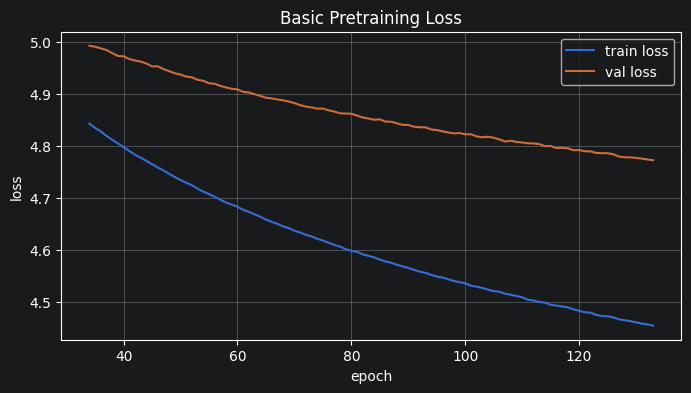

latest epoch: 133
global_step: 29260
train_loss: 4.4536618947982785
val_loss: 4.772017192840576
elapsed: 286.1 sec


In [22]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_epoch_33.pt",
    device=device,
)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
}

EPOCHS_TO_RUN = 100
EVAL_BATCHES = 20
start_time = time.perf_counter()

for epoch in range(start_epoch, start_epoch + EPOCHS_TO_RUN):
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch + 1,
        global_step=global_step,
        path=f"checkpoints/basic_monitor_latest.pt",
    )

    clear_output(wait=True)

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Basic Pretraining Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("latest epoch:", epoch + 1)
    print("global_step:", global_step)
    print("train_loss:", train_loss)
    print("val_loss:", val_loss)
    print("elapsed:", round(time.perf_counter() - start_time, 1), "sec")

    Path("checkpoints/basic_monitor_history.json").write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

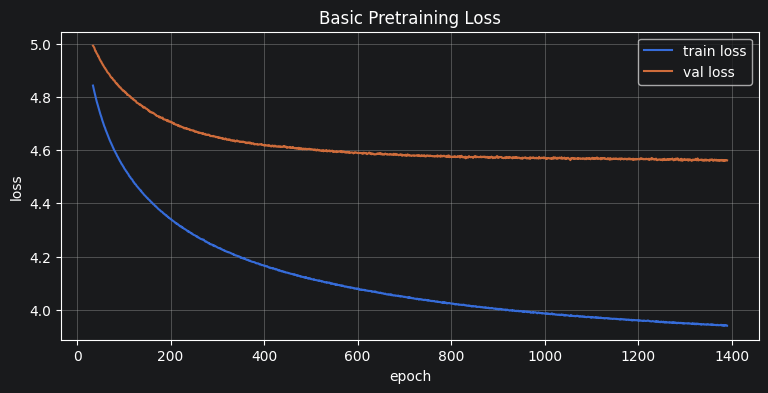

latest epoch: 1390
global_step: 305800
train_loss: 3.940032276240262
val_loss: 4.561598777770996
best_val_loss: 4.559159135818481
elapsed: 3595.8 sec
remaining: 4.2 sec
done
final epoch: 1392
global_step: 306240
best_val_loss: 4.558745741844177
elapsed: 3601.5 sec


In [23]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


MAX_SECONDS = 60 * 60
EVAL_BATCHES = 20
PLOT_EVERY = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

current_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_monitor_latest.pt",
    device=device,
)

history_path = Path("checkpoints/basic_monitor_history.json")
history = json.loads(history_path.read_text(encoding="utf-8"))

best_val_loss = min(history["val_loss"])
print("start epoch:", current_epoch)
print("start global_step:", global_step)
print("best val loss:", best_val_loss)

start_time = time.perf_counter()

while time.perf_counter() - start_time < MAX_SECONDS:
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    current_epoch += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(current_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=current_epoch,
        global_step=global_step,
        path="checkpoints/basic_monitor_latest.pt",
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=current_epoch,
            global_step=global_step,
            path="checkpoints/basic_monitor_best.pt",
        )

    history_path.write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if current_epoch % PLOT_EVERY == 0:
        clear_output(wait=True)

        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["train_loss"], label="train loss")
        plt.plot(history["epoch"], history["val_loss"], label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title("Basic Pretraining Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        elapsed = time.perf_counter() - start_time
        print("latest epoch:", current_epoch)
        print("global_step:", global_step)
        print("train_loss:", train_loss)
        print("val_loss:", val_loss)
        print("best_val_loss:", best_val_loss)
        print("elapsed:", round(elapsed, 1), "sec")
        print("remaining:", round(MAX_SECONDS - elapsed, 1), "sec")

elapsed = time.perf_counter() - start_time

print("done")
print("final epoch:", current_epoch)
print("global_step:", global_step)
print("best_val_loss:", best_val_loss)
print("elapsed:", round(elapsed, 1), "sec")